# Imports

In [1]:
!pip install evaluate
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 10.2 MB/s eta 0:00:00


In [49]:
import pandas as pd
import numpy as np
import re
from transformers import XLNetTokenizer, XLNetForSequenceClassification, TrainingArguments, Trainer, pipeline
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import datasets
import evaluate
import random
import emoji

# Preprocess our data

In [3]:
data_train = pd.read_csv('186 - emotion-labels-train.csv')
data_test = pd.read_csv('186 - emotion-labels-test.csv')
data_val = pd.read_csv('186 - emotion-labels-val.csv')

In [4]:
data_train.head()

,text,label
0,Just got back from seeing @GaryDelaney in Burs...,joy
1,Oh dear an evening of absolute hilarity I don'...,joy
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy
4,I feel so blessed to work with the family that...,joy


In [5]:
data = pd.concat([data_train, data_test, data_val], ignore_index=True)

In [7]:
data['text_clean'] = data['text'].apply(lambda x: emoji.replace_emoji(x, ""))

In [8]:
data['text_clean'] = data['text'].str.replace(r'@[^\s]+', '', regex=True)

In [9]:
data.head(20)

,text,label,text_clean
0,Just got back from seeing @GaryDelaney in Burs...,joy,Just got back from seeing in Burslem. AMAZING...
1,Oh dear an evening of absolute hilarity I don'...,joy,Oh dear an evening of absolute hilarity I don'...
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy,Been waiting all week for this game ❤️❤️❤️ #ch...
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy,": Thank you so much, Gloria! You're so sweet,..."
4,I feel so blessed to work with the family that...,joy,I feel so blessed to work with the family that...
5,"Today I reached 1000 subscribers on YT!! , #go...",joy,"Today I reached 1000 subscribers on YT!! , #go..."
6,"@Singaholic121 Good morning, love! Happy first...",joy,"Good morning, love! Happy first day of fall. ..."
7,#BridgetJonesBaby is the best thing I've seen ...,joy,#BridgetJonesBaby is the best thing I've seen ...
8,Just got back from seeing @GaryDelaney in Burs...,joy,Just got back from seeing in Burslem. AMAZING...
9,@IndyMN I thought the holidays could not get a...,joy,I thought the holidays could not get any more...


<Axes: xlabel='label'>

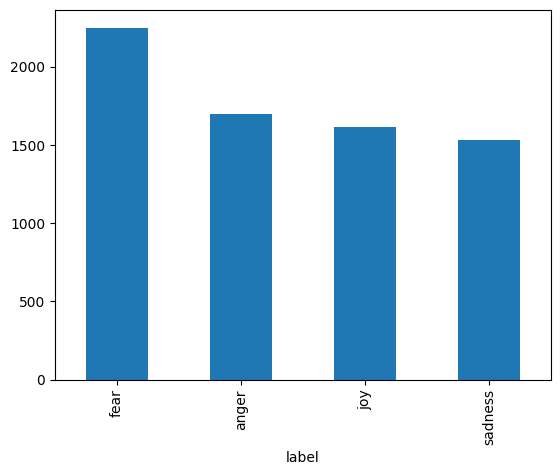

In [11]:
data['label'].value_counts().plot(kind='bar')

In [13]:
g = data.groupby('label')
data = pd.DataFrame(g.apply(lambda x: x.sample(g.size().min()).reset_index(drop=True)))

/tmp/ipykernel_1243/2135407547.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = pd.DataFrame(g.apply(lambda x: x.sample(g.size().min()).reset_index(drop=True)))


<Axes: xlabel='label'>

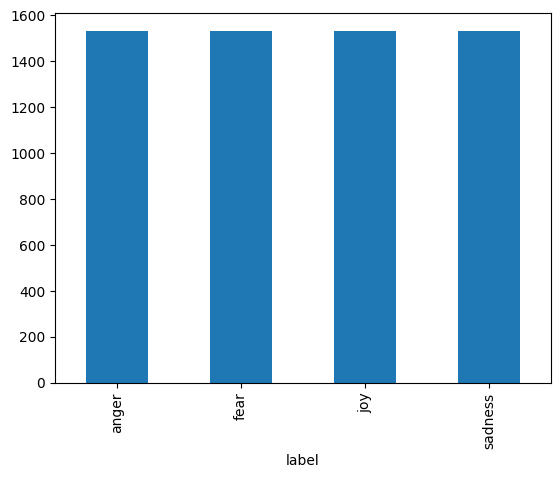

In [14]:
data['label'].value_counts().plot(kind='bar')

In [15]:
data['label_int'] = LabelEncoder().fit_transform(data['label'])

In [16]:
NUM_LABELS = 4

In [17]:
train_split, test_split = train_test_split(data, train_size=0.8)
train_split, val_split = train_test_split(train_split, train_size=0.9)

In [18]:
print(len(train_split))
print(len(test_split))
print(len(val_split))

4414
1227
491


In [21]:
train_df = pd.DataFrame({
    "label": train_split.label_int.values,
    "text": train_split.text_clean.values,
})

test_df = pd.DataFrame({
    "label": test_split.label_int.values,
    "text": test_split.text_clean.values,
})

In [22]:
train_df = datasets.Dataset.from_dict(train_df)
test_df = datasets.Dataset.from_dict(test_df)

In [23]:
dataset_dict = datasets.DatasetDict({"train": train_df, "test": test_df})

In [24]:
dataset_dict

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 4414
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 1227
    })
})

# Create embeddings

In [25]:
tokenizer = XLNetTokenizer.from_pretrained('xlnet-base-cased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [26]:
def tokenize_function(examples):
  return tokenizer(examples["text"], padding="max_length", max_length=128, truncation=True)

In [27]:
tokenized_datasets = dataset_dict.map(tokenize_function, batched=True)

Map:   0%|          | 0/4414 [00:00<?, ? examples/s]

Map:   0%|          | 0/1227 [00:00<?, ? examples/s]

In [28]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['label', 'text', 'input_ids', 'attention_mask'],
        num_rows: 4414
    })
    test: Dataset({
        features: ['label', 'text', 'input_ids', 'attention_mask'],
        num_rows: 1227
    })
})

In [29]:
print(tokenized_datasets['train']['text'][0])

Will WHU be old bill free by the time the game with Chelsea comes around? 😂 😂 😂\nThat will be lively to say the least\n#AFC


In [30]:
print(tokenized_datasets['train']['input_ids'][0])

[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 2825, 543, 18315, 39, 532, 1325, 325, 37, 18, 92, 18, 275, 33, 7919, 909, 199, 82, 17, 0, 17, 0, 17, 0, 17666, 180, 1440, 53, 39, 17017, 22, 248, 18, 390, 17666, 180, 7967, 246, 9513, 4, 3]


In [31]:
tokenizer.decode(5)

'<pad>'

In [34]:
print(tokenized_datasets['train']['attention_mask'][0])

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [35]:
smal_train_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(100))
small_eval_dataset = tokenized_datasets["test"].shuffle(seed=42).select(range(100))

# Fine tune our model

In [36]:
model = XLNetForSequenceClassification.from_pretrained('xlnet-base-cased',
                                                       num_labels=NUM_LABELS,
                                                       id2label={0: 'anger', 1: 'fear', 2: 'joy', 3: 'sadness'})

config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/467M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/467M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

XLNetForSequenceClassification LOAD REPORT from: xlnet-base-cased
Key                             | Status     | 
--------------------------------+------------+-
lm_loss.bias                    | UNEXPECTED | 
lm_loss.weight                  | UNEXPECTED | 
logits_proj.bias                | MISSING    | 
sequence_summary.summary.bias   | MISSING    | 
logits_proj.weight              | MISSING    | 
sequence_summary.summary.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [37]:
metric = evaluate.load("accuracy")

In [38]:
def compute_metrics(eval_pred):
  logits, labels = eval_pred
  predictions = np.argmax(logits, axis=-1)
  return metric.compute(predictions=predictions, references=labels)

In [42]:
training_args = TrainingArguments(output_dir="test_trainer", eval_strategy="epoch", num_train_epochs=3)

In [43]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=smal_train_dataset,
    eval_dataset=small_eval_dataset,
    compute_metrics=compute_metrics,
)

In [44]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.354688,0.360000
2,No log,1.339537,0.290000
3,No log,1.307026,0.340000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=39, training_loss=1.3489703643016326, metrics={'train_runtime': 729.4122, 'train_samples_per_second': 0.411, 'train_steps_per_second': 0.053, 'total_flos': 21366375321600.0, 'train_loss': 1.3489703643016326, 'epoch': 3.0})

# Evaluate model

In [45]:
trainer.evaluate()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 1.3070259094238281,
 'eval_accuracy': 0.34,
 'eval_runtime': 53.5377,
 'eval_samples_per_second': 1.868,
 'eval_steps_per_second': 0.243,
 'epoch': 3.0}

In [46]:
model.save_pretrained("fine_tuned_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [47]:
fine_tuned_model = XLNetForSequenceClassification.from_pretrained("fine_tuned_model")

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

In [51]:
clf = pipeline("text-classification", fine_tuned_model, tokenizer=tokenizer)

In [53]:
rand_int = random.randint(0, len(val_split))
print(val_split['text_clean'][rand_int])
answer = clf(val_split['text_clean'][rand_int], top_k=None)
print(answer)

/tmp/ipykernel_1243/3116462782.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(val_split['text_clean'][rand_int])
/tmp/ipykernel_1243/3116462782.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  answer = clf(val_split['text_clean'][rand_int], top_k=None)


Epicurus~ The man least dependent upon the morrow goes to meet the morrow most cheerfully.
[{'label': 'joy', 'score': 0.5447839498519897}, {'label': 'fear', 'score': 0.1807631105184555}, {'label': 'sadness', 'score': 0.15493790805339813}, {'label': 'anger', 'score': 0.119515061378479}]
